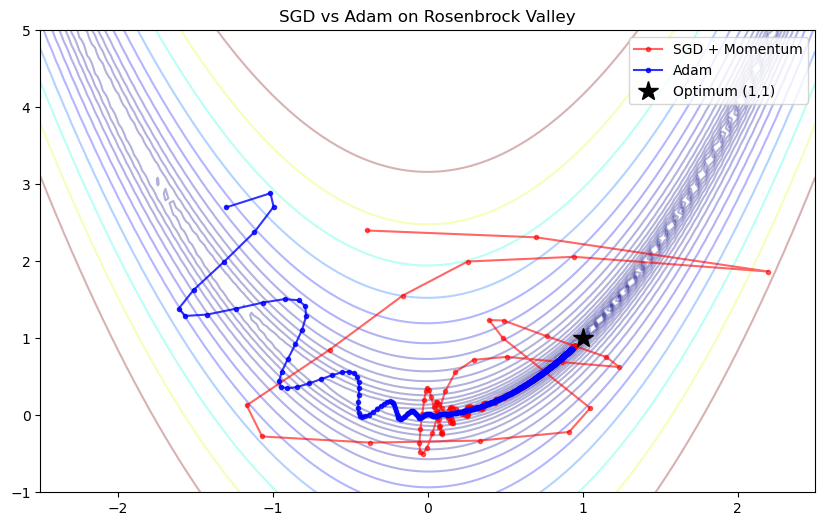

In [7]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

def rosenbrock(tensor):
    x, y = tensor[0], tensor[1]
    return (1 - x)**2 + 100 * (y - x**2)**2

def run_optimization(optimizer_class, lr, iterations=500, **kwargs):
    params = torch.tensor([-2.0, 2.0], dtype=torch.float32, requires_grad=True)
    optimizer = optimizer_class([params], lr=lr, **kwargs)
    history = []

    for _ in range(iterations):
        optimizer.zero_grad()
        loss = rosenbrock(params)
        loss.backward()
        optimizer.step()
        history.append(params.detach().cpu().clone().numpy())

    return np.array(history)

history_sgd = run_optimization(optim.SGD, lr=0.001, momentum=0.9)
history_adam = run_optimization(optim.Adam, lr=0.7)

x = np.linspace(-2.5, 2.5, 100)
y = np.linspace(-1, 5, 100)
X, Y = np.meshgrid(x, y)
Z = (1 - X)**2 + 100 * (Y - X**2)**2

plt.figure(figsize=(10, 6))
plt.contour(X, Y, Z, levels=np.logspace(-1, 3, 20), cmap='jet', alpha=0.3)
plt.plot(history_sgd[:, 0], history_sgd[:, 1], 'r.-', label='SGD + Momentum', alpha=0.6)
plt.plot(history_adam[:, 0], history_adam[:, 1], 'b.-', label='Adam', alpha=0.8)
plt.plot(1, 1, 'k*', markersize=15, label='Optimum (1,1)')
plt.title("SGD vs Adam on Rosenbrock Valley")
plt.legend()
plt.show()